# 2D $\phi^4$ Hamiltonian Truncation on a Circle in Parallel.

Builds the truncated Hamiltonian for an interacting massive scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + H_4 = H_0 + \int dx \frac{\lambda}{4!} :\phi^4:$$

Code used as part of the construction of work arXiv:2607.XXXXX. This code runs the version of the code which parallelises the loop through states.

References: arXiv:2507.15941, arXiv:2110.08273.

In [4]:
# Math imports.
import math
import matplotlib.pyplot as plt
import csv
import numpy as np

# Importing the parallelised code.
import phi4_parallel

%matplotlib inline

E_max: 20
 reduced basis length = 1150 and number of asymmetric states = 916
 total basis length = 2066
845 ms ± 47.7 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 21
 reduced basis length = 1580 and number of asymmetric states = 1289
 total basis length = 2869
832 ms ± 9.51 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 22
 reduced basis length = 2195 and number of asymmetric states = 1852
 total basis length = 4047
953 ms ± 54.7 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 23
 reduced basis length = 2990 and number of asymmetric states = 2569
 total basis length = 5559
3.09 s ± 103 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 24
 reduced basis length = 4116 and number of asymmetric states = 3622
 total basis length = 7738
3.05 s ± 67 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 25
 reduced basis length = 5550 and number of asymmetric states = 4949
 total basis length = 10499
3.11 s ± 112 ms per loop (mean ± 

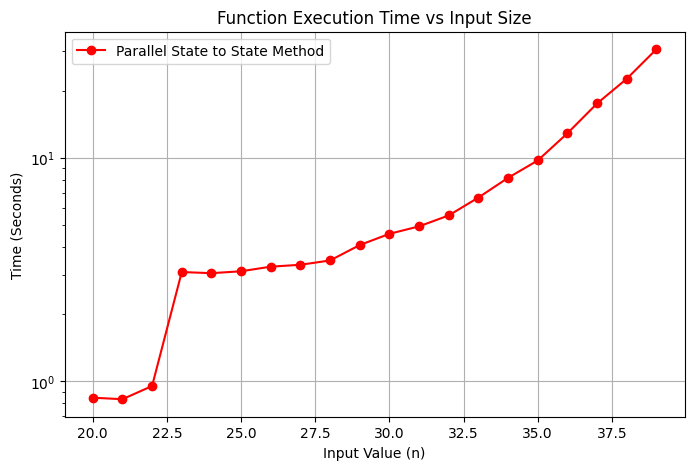

In [10]:
# ---------------------------------
# ---- Prepatation and Inputs -----
# ---------------------------------

# Preparing the parameters for the timing run, and lists for results.
lmbda = 4*np.pi; mQ = 1.; r = 1. # Hamiltonian parameters.
execution_times = []; basis_lengths = []
emax_list = range(20,40) #EMax range.

# Compute prefactor
cphi4 = lmbda*(1/(8*math.pi))*(1/r)


# ---------------------------------
# --- Running the data creation ---
# ---------------------------------

# 1. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = phi4_parallel.effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    dict_basis, hashable_basis, iterSet  = phi4_parallel.basis_even(*phi4_parallel.gen_basis(lmaxeff,emax,mQ,r))
    phi4_parallel.gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.
    print(f' reduced basis length = {len(iterSet)} and number of asymmetric states = {len(dict_basis)-len(iterSet)}')
    print(f' total basis length = {len(dict_basis)}')
    # Timing: 
    duration = %timeit -o -r4 phi4_parallel.transition_matrix_phi4(mQ, r, cphi4, lmaxeff, dict_basis, hashable_basis, iterSet)
    # Add results to relevant lists.
    execution_times.append(duration.average)
    basis_lengths.append(len(dict_basis))


# 2. Export results to a CSV file
csv_filename = "phi4_statetostate_results_parallel.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, lambda = {lmbda}, r = {r}") # To keep track of HT parameters.
    writer.writerow("EMax List")  # Writes emax list onto file header.
    writer.writerow(emax_list) # To keep track of the relevant emax's used.
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 3. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='r', label="Parallel State to State Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()
